### Phase A — Setup
1. Google Colab notebook, synced to GitHub. Fix random seeds (numpy, tensorflow/pytorch, scikit-learn) in the first cell, and log library versions — this is the reproducibility record for the whole run.
2. Install and import: `wfdb`, `numpy`, `pandas`, `matplotlib`, `scikit-learn`, `tensorflow` or `pytorch`, `imbalanced-learn` (for SMOTE), `shap` (for interpretability later).

### Phase B — Data
3. Load MIT-BIH via `wfdb` — not raw pandas, since the native files are WFDB signal + annotation format, not CSV.
4. Preprocess: filter noise, detect R-peaks, segment individual beats, extract AAMI class labels.
5. Exploratory visualization: class distribution bar chart, a handful of raw beat waveforms per class. Look before touching any model.

### Phase C — Splitting and imbalance
6. Patient-grouped k-fold split (`GroupKFold`, patient ID as the group) — roughly 10–12 folds of whole patients, per Section 9.1.
7. Per fold: normalize using only that fold's training-patient statistics, never the full dataset.
8. Per fold: handle class imbalance **on the training portion only** — class weights, SMOTE oversampling, or focal loss for the deep models. The held-out fold stays untouched and imbalanced, since that's what real deployment looks like.
9. Visualize train/test class balance for a couple of folds as a sanity check — this is the original "visualize both sets" step, now done per fold rather than once.
10. Compute the majority-class baseline ("always predict Normal") per fold. This floor number gets reported alongside every real model in the final comparison.

### Phase D — Modeling
11. Build the 12-model pipeline from Section 9.2 (5 families), each with its own import/code section.
12. Hyperparameter search per model, run **inside the training folds only** — either nested cross-validation or one held-out validation slice carved from the training patients. Document what was tried and what won; never tune against the held-out test fold, that is the same leak as Section 9.1 in a different disguise.
13. Train each model once per fold (12 models × ~10–12 folds), timing every run.

### Phase E — Evaluation
14. Extract results into one uniform schema per (model, fold): accuracy, macro-F1, per-class sensitivity/specificity, confusion matrix, training time, chosen hyperparameters.
15. Aggregate confusion matrices across folds into mean sensitivity/specificity matrices per model; report accuracy as mean ± standard deviation across folds, not a single number.
16. Statistical comparison: a paired test (paired t-test or Wilcoxon signed-rank) across folds between the top 2–3 models — this is what the grouped k-fold design in Section 9.1 was for.
17. Interpretability pass on one or two models — attention weights for the CNN-Transformer hybrid, or SHAP values for Random Forest — shown against a few example beats.

### Phase F — Reporting
18. Visualize results: confusion matrices side by side, accuracy/F1 bar charts with error bars from Step 15, a training-time-per-model table.
19. Final report: methods, results (including the floor baseline from Step 10 and the significance test from Step 16), the hyperparameter log from Step 12, the compute/time table, and stated limitations.

```mermaid
flowchart TD
    P1[Setup: seeds, versions, imports] --> P2[Data: load, segment, explore]
    P2 --> P3[Split and imbalance: grouped folds, per-fold balancing, floor baseline]
    P3 --> P4[Modeling: 12 models, tuned per fold, timed]
    P4 --> P5[Evaluation: schema, aggregated matrices, significance test, interpretability]
    P5 --> P6[Reporting: visuals, final writeup]
```

**Status:** this notebook currently implements Phase A (seeds + reproducibility record) and
the single-record exploratory look that opens Phase B, item 5. Segmentation, patient-grouped
splitting (Phase C onward) are not implemented yet.

---
## Phase A — Setup
---
Fixing every random seed the pipeline touches, importing the libraries used throughout
the notebook, and printing a reproducibility record (library versions + hardware) for
this run.

In [1]:
# =============================================================================
# Phase A — Setup: reproducibility record
# Fixes every relevant random seed *before* any other library call, and logs
# the exact library versions used for this run, so the notebook's results can
# be reproduced later (Phase A, item 1).
# =============================================================================

# --- Standard library ---
import os
import sys
import random

# --- Core numerical / data stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- ML / DL stack ---
import torch
import sklearn as skl
import imblearn

# --- Domain-specific / interpretability ---
import wfdb
import shap

SEED = 88

# --- Seed every source of randomness we control ---
os.environ["PYTHONHASHSEED"] = str(SEED)   # hash-based ops (dict/set ordering)
random.seed(SEED)                          # Python's built-in RNG
np.random.seed(SEED)                       # NumPy (also used by pandas/sklearn internally)
torch.manual_seed(SEED)                    # PyTorch CPU RNG

# Note: scikit-learn has no single global seed. Pass random_state=SEED explicitly
# to each estimator / train_test_split / GroupKFold call later in the pipeline.

# GPU-specific seeding. Inert on CPU-only runtimes (this notebook was last run on
# a CPU-only PyTorch build, per the record below) but kept for portability, since
# the plan is to move this onto a GPU runtime for the deep-learning models.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Ask PyTorch to raise an error (instead of silently falling back) if an
# operation has no deterministic implementation available.
try:
    torch.use_deterministic_algorithms(True)
except (AttributeError, RuntimeError):
    pass

# --- Reproducibility record: printed once, kept in this cell's saved output ---
print("--- REPRODUCIBILITY RECORD ---")
print(f"Python version:       {sys.version.split()[0]}")
print(f"NumPy version:        {np.__version__}")
print(f"Pandas version:       {pd.__version__}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Scikit-Learn version: {skl.__version__}")
print(f"Imblearn version:     {imblearn.__version__}")
print(f"WFDB version:         {wfdb.__version__}")
print(f"SHAP version:         {shap.__version__}")
print(f"CUDA available:       {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device:           {torch.cuda.get_device_name(0)}")
print("-------------------------------")

--- REPRODUCIBILITY RECORD ---
Python version:       3.12.10
NumPy version:        1.26.4
Pandas version:       2.2.2
PyTorch version:      2.3.0+cpu
Scikit-Learn version: 1.4.2
Imblearn version:     0.12.2
WFDB version:         4.1.2
SHAP version:         0.45.1
CUDA available:       False
-------------------------------


---
## Phase B — Data: Loading MIT-BIH and Exploratory Visualization
---
Loads a single MIT-BIH record (**100**) directly from PhysioNet via `wfdb.rdrecord()` /
`wfdb.rdann()`, then produces four exploratory plots as a sanity check before any
preprocessing or modeling — Phase B, item 5: "look before touching any model."

* Visualizations used here:
    1. **Raw waveform** — a single lead, unannotated.
    2. **Annotated waveform** — the same signal with cardiologist-labeled beat
       annotations overlaid.
    3. **Dual-lead comparison** — both ECG leads (MLII and V1) stacked, to see how
       the same beats appear on each.
    4. **Poincaré (RR-interval) scatter plot** — RR$_n$ vs RR$_{n+1}$, computed from
       beat annotations across the *entire* record, not just the 10-second display
       window used for the waveform plots.

Note: this is a quick single-record look, not the full-dataset class-balance
visualization across all 48 records — that's still Phase B, item 5's other half, and
comes after segmentation. The per-fold train/test balance plots are Phase C, item 9.

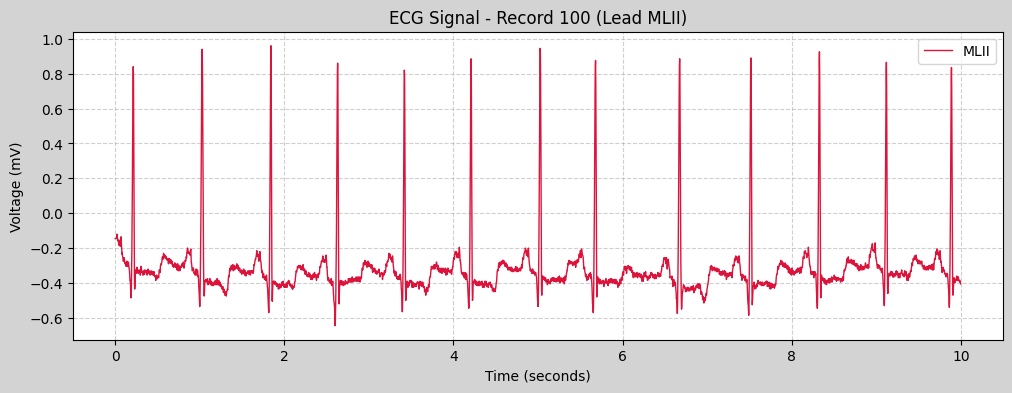

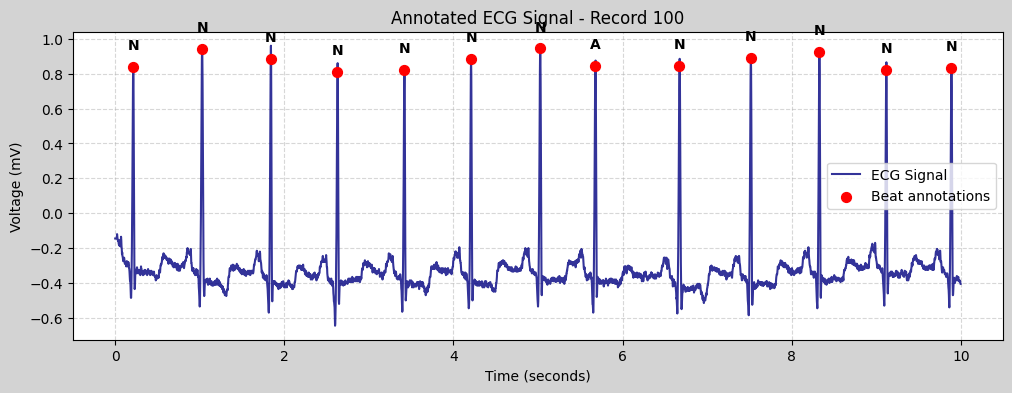

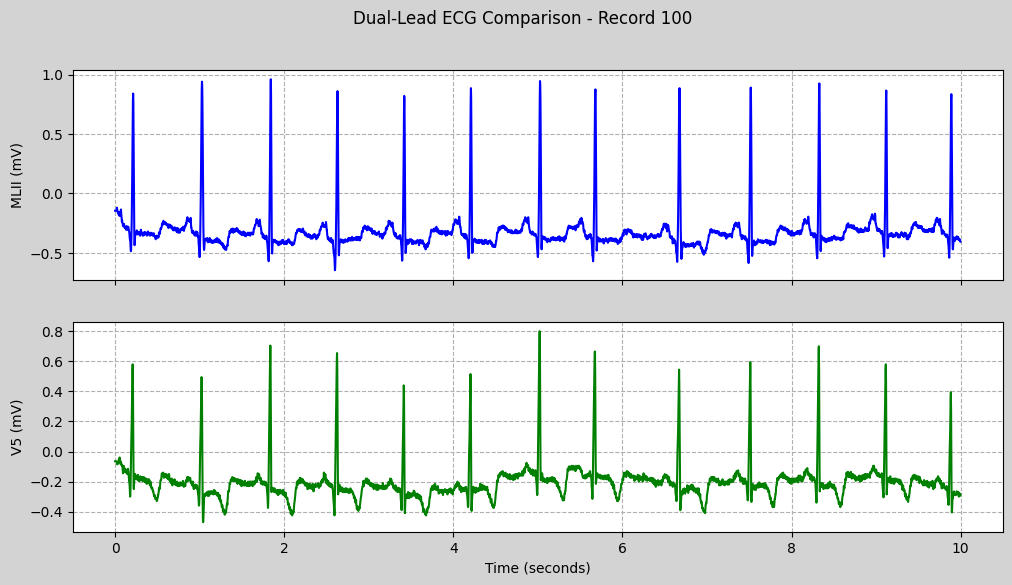

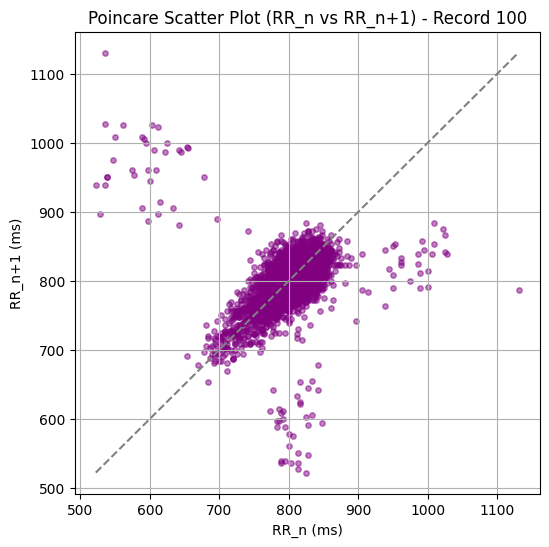

In [3]:
RECORD_ID = "100"     # a representative MIT-BIH record for this first look
PN_DIR = "mitdb"      # PhysioNet database folder for MIT-BIH; lets wfdb stream
                       # the .hea/.dat/.atr files directly, no local download needed
WINDOW_SECONDS = 10    # length of signal shown in the waveform plots

# Standard MIT-BIH *beat* annotation symbols (the AAMI-relevant heartbeat labels).
# Deliberately excludes non-beat annotations such as '+' (rhythm-type change) and
# '~' (signal-quality change) - real, but not R-peaks, and not beats to count.
BEAT_SYMBOLS = {"N", "L", "R", "B", "A", "a", "J", "S", "V",
                 "r", "F", "e", "j", "n", "E", "/", "f", "Q"}

# --- Load signal + annotations directly from PhysioNet ---
db_record = wfdb.rdrecord(RECORD_ID, pn_dir=PN_DIR)
annotation = wfdb.rdann(RECORD_ID, "atr", pn_dir=PN_DIR)

fs = db_record.fs
num_samples = int(WINDOW_SECONDS * fs)
time_axis = np.arange(num_samples) / fs
signal_ch0 = db_record.p_signal[:num_samples, 0]

# Keep only genuine beat annotations for the whole record, then split into
# "inside the display window" (annotated waveform plot) vs. "whole record"
# (RR-interval / Poincare plot, which needs many beats to be meaningful).
is_beat = np.isin(annotation.symbol, list(BEAT_SYMBOLS))
beat_samples_all = annotation.sample[is_beat]
beat_symbols_all = np.asarray(annotation.symbol)[is_beat]

in_window = beat_samples_all < num_samples
peak_samples = beat_samples_all[in_window]
peak_symbols = beat_symbols_all[in_window]
peak_times = peak_samples / fs
peak_voltages = db_record.p_signal[peak_samples, 0]


def plot_raw_signal(time_axis, signal, lead_name, record_name):
    '''Plot 1: a single lead, unannotated -- the rawest possible look at the data.'''
    plt.figure(figsize=(12, 4), facecolor="lightgrey")
    plt.plot(time_axis, signal, color="crimson", linewidth=1, label=lead_name)
    plt.title(f"ECG Signal - Record {record_name} (Lead {lead_name})")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (mV)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc="upper right")
    plt.show()


def plot_annotated_signal(time_axis, signal, peak_times, peak_voltages, peak_symbols, record_name):
    '''Plot 2: same signal, with cardiologist-labeled beat annotations overlaid.'''
    plt.figure(figsize=(12, 4))
    plt.plot(time_axis, signal, color="navy", label="ECG Signal", alpha=0.8)
    plt.scatter(peak_times, peak_voltages, color="red", s=50, zorder=5, label="Beat annotations")
    for t, v, symbol in zip(peak_times, peak_voltages, peak_symbols):
        plt.text(t, v + 0.1, symbol, fontsize=10, fontweight="bold", ha="center")
    plt.title(f"Annotated ECG Signal - Record {record_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (mV)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.show()


def plot_dual_lead(time_axis, signal_ch0, signal_ch1, lead0_name, lead1_name, record_name):
    '''Plot 3: both ECG leads stacked, to compare how the same beats look on each.'''
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(time_axis, signal_ch0, color="blue")
    axes[0].set_ylabel(f"{lead0_name} (mV)")
    axes[0].grid(True, linestyle="--")
    axes[1].plot(time_axis, signal_ch1, color="green")
    axes[1].set_ylabel(f"{lead1_name} (mV)")
    axes[1].set_xlabel("Time (seconds)")
    axes[1].grid(True, linestyle="--")
    plt.suptitle(f"Dual-Lead ECG Comparison - Record {record_name}")
    plt.show()


def plot_poincare(rr_n, rr_n_plus_1, record_name):
    '''Plot 4: Poincare scatter of consecutive RR-intervals -- a quick visual read
    on heart-rate variability/regularity, and a preview of the RR-interval features
    the classical-ML baseline will use later in the pipeline.'''
    plt.figure(figsize=(6, 6))
    plt.scatter(rr_n, rr_n_plus_1, color="purple", alpha=0.5, s=15)
    axis_min = min(rr_n.min(), rr_n_plus_1.min())
    axis_max = max(rr_n.max(), rr_n_plus_1.max())
    plt.plot([axis_min, axis_max], [axis_min, axis_max], color="gray", linestyle="--")  # identity line
    plt.title(f"Poincare Scatter Plot (RR_n vs RR_n+1) - Record {record_name}")
    plt.xlabel("RR_n (ms)")
    plt.ylabel("RR_n+1 (ms)")
    plt.grid(True)
    plt.show()


# --- Run the four exploratory visualizations, in the order listed above ---
plot_raw_signal(time_axis, signal_ch0, db_record.sig_name[0], db_record.record_name)

plot_annotated_signal(time_axis, signal_ch0, peak_times, peak_voltages, peak_symbols, db_record.record_name)

plot_dual_lead(time_axis, db_record.p_signal[:num_samples, 0], db_record.p_signal[:num_samples, 1],
               db_record.sig_name[0], db_record.sig_name[1], db_record.record_name)

# RR-intervals from every beat annotation in the record (not just the 10-second
# display window above) -- a Poincare plot needs many beats to be meaningful.
rr_intervals = np.diff(beat_samples_all) / fs * 1000  # milliseconds
rr_n = rr_intervals[:-1]
rr_n_plus_1 = rr_intervals[1:]
plot_poincare(rr_n, rr_n_plus_1, db_record.record_name)